# Trajectory Quality Labeling for SFT Data Curation

Analyzes rollout trajectories against ground-truth fact graphs to label each step as:

- **high_value**: Well-reasoned actions aligned with the ground truth, good SFT training data
- **neutral**: Routine / boilerplate steps (setup, imports, cd) — harmless but low signal
- **harmful**: Wrong decisions, tool misuse, redundant exploration, information-less actions, unnecessary validation

Uses GLM-5 (port 8000) to perform the labeling with the fact graph as reference.

In [20]:
# ── Configuration ──

# Path to full evaluation output
OUTPUT_JSONL = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/output.jsonl"

# Path to preprocessed fact graphs
PREPROCESS_DIR = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/preprocess/swegym_v6_phase1"

# LLM endpoint
LLM_BASE_URL = "http://127.0.0.1:8000/v1"
LLM_MODEL = "zai-org/GLM-5-FP8"

# Which instance to analyze (set to None to pick interactively)
TARGET_INSTANCE_ID = None  # e.g., "getmoto__moto-4787"

# Max chars per step content in the prompt (truncate long outputs)
MAX_STEP_CONTENT_CHARS = 3000

# How many steps to send per LLM batch (to stay within context window)
STEPS_PER_BATCH = 30

In [21]:
import json
import os
import copy
import time
import textwrap
from collections import Counter
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from openai import OpenAI
except ImportError:
    print("openai package not installed. Run: pip install openai")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

## 1. Load Data

In [9]:
# Build index of available instances in output.jsonl
# (streaming read — only parse instance_id to avoid loading entire file)
instance_index: dict[str, int] = {}  # instance_id -> byte offset

with open(OUTPUT_JSONL, "r") as f:
    while True:
        offset = f.tell()
        line = f.readline()
        if not line:
            break
        # Quick parse: extract instance_id without loading the whole JSON
        try:
            # Find instance_id near the start of the line
            entry = json.loads(line)
            iid = entry.get("instance_id", "")
            if iid:
                instance_index[iid] = offset
        except json.JSONDecodeError:
            continue

print(f"Indexed {len(instance_index)} instances from output.jsonl")

# Also check which have fact graphs
instances_with_facts = set()
for entry in os.listdir(PREPROCESS_DIR):
    if os.path.isfile(os.path.join(PREPROCESS_DIR, entry, "stage2_facts.json")):
        instances_with_facts.add(entry)

available = sorted(set(instance_index.keys()) & instances_with_facts)
print(f"Instances with both trajectory + fact graph: {len(available)}")

Indexed 2119 instances from output.jsonl
Instances with both trajectory + fact graph: 1629


In [22]:
# Select target instance
if TARGET_INSTANCE_ID is None:
    # Pick the first available one as default
    TARGET_INSTANCE_ID = available[0]
    print(f"Auto-selected instance: {TARGET_INSTANCE_ID}")
    print(f"Set TARGET_INSTANCE_ID in config cell to pick a specific one.")
    print(f"\nFirst 20 available instances:")
    for iid in available[:20]:
        print(f"  {iid}")
else:
    assert TARGET_INSTANCE_ID in available, (
        f"{TARGET_INSTANCE_ID} not found in available instances"
    )
    print(f"Target instance: {TARGET_INSTANCE_ID}")

Auto-selected instance: Project-MONAI__MONAI-1012
Set TARGET_INSTANCE_ID in config cell to pick a specific one.

First 20 available instances:
  Project-MONAI__MONAI-1012
  Project-MONAI__MONAI-1030
  Project-MONAI__MONAI-1065
  Project-MONAI__MONAI-1532
  Project-MONAI__MONAI-1571
  Project-MONAI__MONAI-1684
  Project-MONAI__MONAI-1836
  Project-MONAI__MONAI-1884
  Project-MONAI__MONAI-1961
  Project-MONAI__MONAI-2061
  Project-MONAI__MONAI-2096
  Project-MONAI__MONAI-2238
  Project-MONAI__MONAI-2305
  Project-MONAI__MONAI-2325
  Project-MONAI__MONAI-2421
  Project-MONAI__MONAI-2454
  Project-MONAI__MONAI-2465
  Project-MONAI__MONAI-2482
  Project-MONAI__MONAI-2492
  Project-MONAI__MONAI-2508


In [23]:
# Load trajectory for target instance
with open(OUTPUT_JSONL, "r") as f:
    f.seek(instance_index[TARGET_INSTANCE_ID])
    line = f.readline()
    output_entry = json.loads(line)

history = output_entry["history"]
print(f"Loaded trajectory: {len(history)} events")
print(f"Error: {output_entry.get('error')}")
print(f"Git patch length: {len(output_entry.get('test_result', {}).get('git_patch', '') or '')} chars")

# Event type summary
type_counts = Counter()
for h in history:
    a = h.get("action", "")
    o = h.get("observation", "")
    if a:
        type_counts[f"action:{a}"] += 1
    if o:
        type_counts[f"obs:{o}"] += 1

print("\nEvent type distribution:")
for k, v in type_counts.most_common():
    print(f"  {k}: {v}")

Loaded trajectory: 129 events
Error: None
Git patch length: 949 chars

Event type distribution:
  action:run: 33
  obs:run: 33
  action:read: 14
  obs:read: 14
  action:edit: 12
  obs:edit: 12
  action:think: 3
  obs:think: 3
  action:system: 1
  action:message: 1
  action:recall: 1
  obs:recall: 1
  action:finish: 1


In [24]:
# Load fact graph for target instance
facts_path = os.path.join(PREPROCESS_DIR, TARGET_INSTANCE_ID, "stage2_facts.json")
with open(facts_path, "r") as f:
    fact_graph = json.load(f)

nodes = fact_graph["nodes"]
fact_nodes = [n for n in nodes if n["node_type"] == "fact"]
artifact_nodes = [n for n in nodes if n["node_type"] != "fact"]

print(f"Fact graph: {len(nodes)} nodes ({len(fact_nodes)} facts, {len(artifact_nodes)} artifacts)")
print()
for n in nodes:
    nt = n["node_type"]
    nid = n["id"]
    if nt == "fact":
        stmt = n.get("statement", "")[:100]
        print(f"  [{nid}] {nt} ({n.get('type','')}) — {stmt}")
    elif nt == "code_edit":
        print(f"  [{nid}] {nt} — {n.get('file', '?')} ({n.get('action_type', 'str_replace')})")
    elif nt == "reproduce_script":
        print(f"  [{nid}] {nt} — {n.get('description', '')[:80]}")
    else:
        desc = n.get("description", n.get("text", ""))[:80]
        print(f"  [{nid}] {nt} — {desc}")

Fact graph: 24 nodes (15 facts, 9 artifacts)

  [f1] fact (static) — The problem statement reports that when a NIfTI file has multiple periods in its name (e.g., 1.3.12.
  [f2] fact (static) — The create_file_basename function in monai/data/utils.py (lines 428-462) uses a while loop (lines 44
  [f3] fact (dynamic) — When os.path.splitext is called iteratively on '1.3.12.2.1107.5.4.4.145.nii.gz', it produces the cha
  [f4] fact (dynamic) — Calling create_file_basename('seg', '1.3.12.2.1107.5.4.4.145.nii.gz', '/tmp/output') returns '/tmp/o
  [f5] fact (dynamic) — The only compound extension that needs special handling is '.nii.gz' (gzipped NIfTI). For this case,
  [f6] fact (static) — The NiftiSaver class (monai/data/nifti_saver.py) supports output_ext values of '.nii.gz' and '.nii' 
  [f7] fact (static) — The NiftiSaver.save method at line 102 calls create_file_basename(self.output_postfix, filename, sel
  [f8] fact (static) — The is_supported_format function in monai/data/utils.py (lin

## 2. Extract Agent Steps

Pair each agent action with its corresponding observation to form a "step".

In [25]:
def extract_steps(history: list[dict]) -> list[dict]:
    """Extract meaningful agent steps from raw history.

    Each step = one agent action + its observation (if any).
    Skips system/user setup events and pure observations without actions.
    """
    steps = []
    i = 0
    while i < len(history):
        event = history[i]
        action = event.get("action", "")
        source = event.get("source", "")

        # Only consider agent actions
        if source == "agent" and action and action not in ("system",):
            step = {
                "step_num": len(steps),
                "event_index": i,
                "action_type": action,
                "action_event": event,
                "observation_event": None,
            }

            # Look for the corresponding observation
            if i + 1 < len(history) and history[i + 1].get("observation"):
                step["observation_event"] = history[i + 1]
                i += 2
            else:
                i += 1

            steps.append(step)
        else:
            i += 1

    return steps


def format_step_for_prompt(step: dict, max_chars: int = MAX_STEP_CONTENT_CHARS) -> str:
    """Format a step into a concise text representation for the LLM prompt."""
    action = step["action_event"]
    obs = step["observation_event"]
    action_type = step["action_type"]
    args = action.get("args", {})

    lines = [f"### Step {step['step_num']}  [action: {action_type}]"]

    # Agent's reasoning
    thought = args.get("thought", "") or ""
    # Also check for content in model_response message
    tool_meta = action.get("tool_call_metadata", {})
    model_resp = tool_meta.get("model_response", {}) if tool_meta else {}
    choices = model_resp.get("choices", []) if model_resp else []
    llm_content = ""
    if choices:
        msg = choices[0].get("message", {})
        llm_content = msg.get("content", "") or ""

    if llm_content and llm_content != thought:
        lines.append(f"**LLM reasoning**: {llm_content[:max_chars]}")
    elif thought:
        lines.append(f"**Thought**: {thought[:max_chars]}")

    # Action content
    if action_type == "run":
        lines.append(f"**Command**: `{args.get('command', '')[:max_chars]}`")
    elif action_type == "read":
        path = args.get("path", "")
        start = args.get("start_line", "")
        end = args.get("end_line", "")
        lines.append(f"**Read**: {path} (lines {start}-{end})")
    elif action_type == "edit":
        path = args.get("path", "")
        old_str = (args.get("old_str", "") or "")[:400]
        new_str = (args.get("new_str", "") or "")[:400]
        lines.append(f"**Edit**: {path}")
        if args.get("command") == "create":
            content = (args.get("file_text", "") or "")[:max_chars]
            lines.append(f"  create file: {content}")
        else:
            lines.append(f"  old: {old_str}")
            lines.append(f"  new: {new_str}")
    elif action_type == "think":
        lines.append(f"**Think**: {thought[:max_chars]}")
    elif action_type == "message":
        content = args.get("content", "")[:max_chars]
        lines.append(f"**Message**: {content}")
    elif action_type == "finish":
        lines.append("**Finish**: Agent declares task complete.")
    elif action_type == "run_ipython":
        code = args.get("code", "")[:max_chars]
        lines.append(f"**IPython**: {code}")
    else:
        lines.append(f"**Args**: {json.dumps(args)[:max_chars]}")

    # Observation
    if obs:
        obs_type = obs.get("observation", "")
        obs_content = (obs.get("content", "") or "")[:max_chars]
        extras = obs.get("extras", {})
        if obs_type == "run":
            metadata = extras.get("metadata", {})
            exit_code = metadata.get("exit_code", "?")
            lines.append(f"**Output** (exit_code={exit_code}): {obs_content}")
        elif obs_type == "read":
            lines.append(f"**File content**: {obs_content}")
        elif obs_type == "edit":
            lines.append(f"**Edit result**: {obs_content}")
        elif obs_type == "error":
            lines.append(f"**ERROR**: {obs_content}")
        elif obs_content:
            lines.append(f"**Observation** ({obs_type}): {obs_content}")

    return "\n".join(lines)


steps = extract_steps(history)
print(f"Extracted {len(steps)} agent steps")

# Show breakdown
step_types = Counter(s["action_type"] for s in steps)
for k, v in step_types.most_common():
    print(f"  {k}: {v}")

Extracted 63 agent steps
  run: 33
  read: 14
  edit: 12
  think: 3
  finish: 1


In [14]:
# Preview a few formatted steps
for s in steps[:3]:
    print(format_step_for_prompt(s))
    print("---")

### Step 0  [action: think]
**LLM reasoning**: I'll help you fix the bug in SegmentationSaver. Let's start by understanding the problem and then systematically work through the solution.

## Phase 1: READING - Understanding the Problem
**Think**: I'll help you fix the bug in SegmentationSaver. Let's start by understanding the problem and then systematically work through the solution.

## Phase 1: READING - Understanding the Problem
Let me analyze the issue:

1. **Problem**: When saving a segmentation file with multiple periods in the filename (e.g., `1.3.12.2.1107.5.4.4.145.nii.gz`), the resulting filename is truncated to `1.nii.gz`.

2. **Root Cause**: The `create_file_basename` function in `monai/data/utils.py` has a while loop that repeatedly splits the filename on the extension:
   ```python
   filename, ext = os.path.splitext(filename)
   while ext != "":  
        filename, ext = os.path.splitext(filename)
   ```
   This loop keeps stripping extensions until there's no extension 

## 3. Build Fact Graph Reference

Format the fact graph into a compact reference for the LLM prompt.

In [26]:
def format_fact_graph_for_prompt(nodes: list[dict]) -> str:
    """Format the fact graph as a compact reference document."""
    lines = ["# Ground Truth Fact Graph\n"]
    lines.append("This is the oracle fact graph for this task. It represents the ideal ")
    lines.append("investigation path and correct fix. Use it to judge whether each step ")
    lines.append("in the trajectory aligns with or deviates from the ground truth.\n")

    # Group by type
    facts = [n for n in nodes if n["node_type"] == "fact"]
    edits = [n for n in nodes if n["node_type"] == "code_edit"]
    repros = [n for n in nodes if n["node_type"] == "reproduce_script"]
    analyses = [n for n in nodes if n["node_type"] == "issue_analysis"]
    plans = [n for n in nodes if n["node_type"] == "fix_plan"]
    validations = [n for n in nodes if n["node_type"] == "validation"]
    others = [n for n in nodes if n["node_type"] not in
              ("fact", "code_edit", "reproduce_script", "issue_analysis", "fix_plan", "validation")]

    if facts:
        lines.append("\n## Investigation Facts")
        lines.append("Facts the agent should discover during exploration:\n")
        for f in facts:
            dep = f", depends_on={f['depends_on']}" if f.get("depends_on") else ""
            lines.append(f"- **[{f['id']}]** ({f.get('type','')}) {f['statement'][:300]}{dep}")
            unlocker = f.get("unlocker", {})
            if unlocker:
                lines.append(f"  - Discovery action: `{unlocker.get('action', '')}` → {unlocker.get('observation', '')[:200]}")

    if repros:
        lines.append("\n## Reproduction Scripts")
        for r in repros:
            lines.append(f"- **[{r['id']}]** {r.get('description', '')[:200]}")
            lines.append(f"  - Expected output before fix: {r.get('output_before_fix', '')[:200]}")
            lines.append(f"  - Expected output after fix: {r.get('output_after_fix', '')[:200]}")

    if analyses:
        lines.append("\n## Issue Analysis")
        for a in analyses:
            lines.append(f"- **[{a['id']}]** {a.get('text', '')[:400]}")

    if plans:
        lines.append("\n## Fix Plan")
        for p in plans:
            lines.append(f"- **[{p['id']}]** {p.get('text', '')[:400]}")

    if edits:
        lines.append("\n## Required Code Edits")
        lines.append("These are the exact code changes needed to fix the bug:\n")
        for e in edits:
            lines.append(f"- **[{e['id']}]** File: `{e.get('file', '')}` (action: {e.get('action_type', 'str_replace')})")
            old = (e.get("old_str", "") or "")[:300]
            new = (e.get("new_str", "") or "")[:300]
            if old:
                lines.append(f"  - Remove: ```{old}```")
            if new:
                lines.append(f"  - Insert: ```{new}```")

    if validations:
        lines.append("\n## Validation")
        for v in validations:
            lines.append(f"- **[{v['id']}]** Command: `{v.get('command', '')[:200]}`")
            lines.append(f"  - Expected: {v.get('expected_output', '')[:200]}")

    if others:
        lines.append("\n## Other Nodes")
        for o in others:
            lines.append(f"- **[{o['id']}]** ({o['node_type']}) {str(o.get('text', o.get('description', '')))[:200]}")

    return "\n".join(lines)


fact_graph_text = format_fact_graph_for_prompt(nodes)
print(f"Fact graph prompt: {len(fact_graph_text)} chars")
print(fact_graph_text[:2000])
print("...")

Fact graph prompt: 12715 chars
# Ground Truth Fact Graph

This is the oracle fact graph for this task. It represents the ideal 
investigation path and correct fix. Use it to judge whether each step 
in the trajectory aligns with or deviates from the ground truth.


## Investigation Facts
Facts the agent should discover during exploration:

- **[f1]** (static) The problem statement reports that when a NIfTI file has multiple periods in its name (e.g., 1.3.12.2.1107.5.4.4.145.nii.gz, a DICOM-style naming convention), the SegmentationSaver truncates the filename to just '1.nii.gz', losing all meaningful identifier information.
  - Discovery action: `[view] problem_statement` → User reports that filenames like 1.3.12.2.1107.5.4.4.145.nii.gz get truncated to 1.nii.gz when saved. The user identifies the root cause as the while loop in create_file_basename in monai/data/utils.p
- **[f2]** (static) The create_file_basename function in monai/data/utils.py (lines 428-462) uses a while loop (line

## 4. LLM Labeling

In [27]:
LABELING_SYSTEM_PROMPT = """\
You are an expert code agent trajectory evaluator. Your task is to label each step
in an agent's problem-solving trajectory as high-value, neutral, or harmful for
supervised fine-tuning (SFT) data curation.

You are given:
1. A GROUND TRUTH FACT GRAPH: the ideal investigation path, correct analysis, and
   required code changes for solving a software bug.
2. A TRAJECTORY: the agent's actual step-by-step actions and observations.

For each step, assign ONE label and provide a brief reason:

## Labels

### "high_value" — Good SFT training signal
Steps that demonstrate desirable behavior:
- Targeted file exploration that aligns with facts in the ground truth
- Correct reproduction of the bug as described in the fact graph
- Accurate root cause analysis matching the ground truth
- Code edits that match or approximate the required fixes
- Efficient, well-scoped validation of the fix
- Well-reasoned thinking/planning that progresses toward the solution
- Actions that directly discover facts listed in the fact graph

### "neutral" — Low signal, harmless boilerplate
Steps that are routine and neither helpful nor harmful:
- Standard environment setup (cd, ls, pwd)
- Reading the problem statement (first time only)
- Generic project structure exploration (if brief)
- Acknowledging task completion (finish action)

### "harmful" — Bad SFT training signal
Steps that teach the model undesirable behavior:
- **wrong_direction**: Investigating files/code unrelated to the ground truth fix
- **redundant_exploration**: Re-reading files already read, re-running same commands
- **information_less**: Commands that produce no useful information (e.g., grepping
  for irrelevant terms, reading unrelated files)
- **tool_misuse**: Using wrong tool for the job, malformed commands, syntax errors
- **incorrect_edit**: Code changes that don't match the ground truth and introduce
  bugs or are in wrong files
- **excessive_validation**: Over-long, repetitive test runs beyond what's needed
  to verify the fix
- **hallucination**: Agent claims something about the code that contradicts the
  fact graph or observed output
- **premature_action**: Implementing a fix before understanding the problem
  (skipping exploration/analysis)
- **backtracking**: Undoing correct work or reverting to a worse state

## Output Format

Return a JSON array where each element corresponds to a step:

```json
[
  {
    "step": 0,
    "label": "high_value",
    "sub_label": "",
    "reason": "Reads the exact file containing the bug as indicated by fact f3.",
    "related_facts": ["f3"]
  },
  {
    "step": 1,
    "label": "harmful",
    "sub_label": "redundant_exploration",
    "reason": "Re-reads the same file that was already fully read in step 0.",
    "related_facts": []
  }
]
```

Rules:
- `sub_label` is required for "harmful" steps (one of: wrong_direction,
  redundant_exploration, information_less, tool_misuse, incorrect_edit,
  excessive_validation, hallucination, premature_action, backtracking).
  For "high_value" and "neutral" steps, set sub_label to "".
- `related_facts` lists fact graph node IDs (e.g., ["f1", "f3", "edit1"]) that
  the step relates to. Empty list if unrelated.
- `reason` should be 1-2 sentences max.
- Be precise: a step exploring a file IS high_value if that file is mentioned in
  the fact graph, even if the agent doesn't explicitly cite the fact.
- Consider CONTEXT: a step may be neutral on its own but harmful if it's the 3rd
  time the agent reads the same file.
- Return ONLY the JSON array, no other text.
"""

In [28]:
def build_labeling_prompt(
    fact_graph_text: str,
    steps: list[dict],
    batch_start: int,
    batch_end: int,
    previous_labels: list[dict] | None = None,
) -> str:
    """Build the user prompt for a batch of steps."""
    parts = [fact_graph_text, "\n\n---\n\n"]

    # Include summary of previous labels for context continuity
    if previous_labels:
        parts.append("# Previously Labeled Steps (for context)\n")
        for lab in previous_labels[-10:]:  # last 10 for context
            parts.append(
                f"- Step {lab['step']}: **{lab['label']}** "
                f"{'(' + lab['sub_label'] + ') ' if lab.get('sub_label') else ''}"
                f"— {lab['reason']}\n"
            )
        parts.append("\n---\n\n")

    parts.append("# Trajectory Steps to Label\n\n")
    for s in steps[batch_start:batch_end]:
        parts.append(format_step_for_prompt(s))
        parts.append("\n\n")

    parts.append(
        f"\nLabel steps {batch_start} through {batch_end - 1}. "
        f"Return a JSON array with {batch_end - batch_start} elements."
    )

    return "".join(parts)


# Preview first batch prompt
preview = build_labeling_prompt(fact_graph_text, steps, 0, min(3, len(steps)))
print(f"Preview prompt length: {len(preview)} chars")
print(preview[-500:])

Preview prompt length: 18838 chars
r.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/nifti_reader.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/nifti_saver.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/nifti_writer.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/png_saver.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/png_writer.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/synthetic.py
/workspace/Project-MONAI__MONAI__0.2/monai/data/utils.py


Label steps 0 through 2. Return a JSON array with 3 elements.


In [29]:
def call_llm_for_labels(
    client: OpenAI,
    fact_graph_text: str,
    steps: list[dict],
    batch_start: int,
    batch_end: int,
    previous_labels: list[dict] | None = None,
    max_retries: int = 3,
) -> list[dict]:
    """Call LLM to label a batch of steps. Returns list of label dicts."""
    prompt = build_labeling_prompt(
        fact_graph_text, steps, batch_start, batch_end, previous_labels
    )

    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {"role": "system", "content": LABELING_SYSTEM_PROMPT},
                    {"role": "user", "content": prompt},
                ],
                temperature=0.1,
                max_tokens=4096,
            )
            raw = resp.choices[0].message.content.strip()

            # Extract JSON from response (handle markdown code blocks)
            if raw.startswith("```"):
                # Strip ```json ... ```
                lines = raw.split("\n")
                json_lines = []
                in_block = False
                for line in lines:
                    if line.strip().startswith("```") and not in_block:
                        in_block = True
                        continue
                    elif line.strip() == "```" and in_block:
                        break
                    elif in_block:
                        json_lines.append(line)
                raw = "\n".join(json_lines)

            labels = json.loads(raw)
            expected_count = batch_end - batch_start
            if len(labels) != expected_count:
                print(f"  Warning: expected {expected_count} labels, got {len(labels)}. Retrying...")
                continue

            # Validate labels
            valid_labels = {"high_value", "neutral", "harmful"}
            for lab in labels:
                if lab.get("label") not in valid_labels:
                    print(f"  Warning: invalid label '{lab.get('label')}'. Retrying...")
                    break
            else:
                return labels

        except json.JSONDecodeError as e:
            print(f"  JSON parse error on attempt {attempt + 1}: {e}")
            if attempt == max_retries - 1:
                print(f"  Raw response: {raw[:500]}")
        except Exception as e:
            print(f"  LLM error on attempt {attempt + 1}: {e}")
            time.sleep(2)

    # Fallback: return unlabeled entries
    print(f"  FAILED to get labels for steps {batch_start}-{batch_end - 1}")
    return [
        {"step": i, "label": "unknown", "sub_label": "", "reason": "LLM labeling failed", "related_facts": []}
        for i in range(batch_start, batch_end)
    ]

In [30]:
# Run labeling across all steps in batches
client = OpenAI(base_url=LLM_BASE_URL, api_key="dummy")

all_labels: list[dict] = []
n_steps = len(steps)
n_batches = (n_steps + STEPS_PER_BATCH - 1) // STEPS_PER_BATCH

print(f"Labeling {n_steps} steps in {n_batches} batches of {STEPS_PER_BATCH}...")
print()

for batch_idx in range(n_batches):
    batch_start = batch_idx * STEPS_PER_BATCH
    batch_end = min(batch_start + STEPS_PER_BATCH, n_steps)

    print(f"Batch {batch_idx + 1}/{n_batches}: steps {batch_start}-{batch_end - 1} ... ", end="", flush=True)
    t0 = time.time()

    batch_labels = call_llm_for_labels(
        client, fact_graph_text, steps,
        batch_start, batch_end,
        previous_labels=all_labels if all_labels else None,
    )

    # Ensure step numbers are correct
    for i, lab in enumerate(batch_labels):
        lab["step"] = batch_start + i

    all_labels.extend(batch_labels)
    elapsed = time.time() - t0
    label_summary = Counter(l["label"] for l in batch_labels)
    print(f"done ({elapsed:.1f}s) — {dict(label_summary)}")

print(f"\nTotal: {len(all_labels)} steps labeled")

Labeling 63 steps in 3 batches of 30...

Batch 1/3: steps 0-29 ... 

done (176.6s) — {'neutral': 6, 'high_value': 21, 'harmful': 3}
Batch 2/3: steps 30-59 ... done (164.4s) — {'high_value': 23, 'neutral': 5, 'harmful': 2}
Batch 3/3: steps 60-62 ... done (23.8s) — {'high_value': 1, 'neutral': 2}

Total: 63 steps labeled


## 5. Results Overview

In [31]:
# Build results DataFrame
result_rows = []
for lab in all_labels:
    step_idx = lab["step"]
    step = steps[step_idx] if step_idx < len(steps) else None
    result_rows.append({
        "step": lab["step"],
        "action_type": step["action_type"] if step else "",
        "label": lab["label"],
        "sub_label": lab.get("sub_label", ""),
        "reason": lab["reason"],
        "related_facts": ", ".join(lab.get("related_facts", [])),
    })

df_labels = pd.DataFrame(result_rows)

# Color-coded display
def color_label(val):
    colors = {
        "high_value": "background-color: #d4edda",
        "neutral": "background-color: #fff3cd",
        "harmful": "background-color: #f8d7da",
        "unknown": "background-color: #e2e3e5",
    }
    return colors.get(val, "")

display(df_labels.style.map(color_label, subset=["label"]))

,step,action_type,label,sub_label,reason,related_facts
0,0,think,neutral,,Initial thinking about the problem statement - standard problem understanding phase.,f1
1,1,read,neutral,,Standard project directory exploration to understand structure.,
2,2,read,neutral,,Standard exploration of monai/data directory to locate relevant files.,
3,3,read,high_value,,Reading the utils.py file that contains the buggy create_file_basename function mentioned in f2.,f2
4,4,run,high_value,,Finding the exact line number of create_file_basename function in utils.py.,f2
5,5,read,high_value,,Reading the buggy create_file_basename function with the while loop at lines 447-449 as described in f2.,f2
6,6,read,high_value,,"Reading test file to understand how SegmentationSaver is tested, relates to f12 about existing tests.",f12
7,7,read,high_value,,"Reading NiftiSaver to understand how create_file_basename is called, relates to f7.",f7
8,8,read,neutral,,Exploring PNGSaver for pattern understanding - not directly related to the fix.,
9,9,run,high_value,,"Checking for existing tests of create_file_basename, relates to f12.",f12


In [32]:
# Summary statistics
label_counts = df_labels["label"].value_counts()
n_total = len(df_labels)

print(f"Instance: {TARGET_INSTANCE_ID}")
print(f"Total steps: {n_total}")
print()
print("── Label Distribution ──")
for label in ["high_value", "neutral", "harmful", "unknown"]:
    count = label_counts.get(label, 0)
    pct = count / n_total * 100 if n_total > 0 else 0
    print(f"  {label:15s}: {count:3d} ({pct:5.1f}%)")

# Sub-label breakdown for harmful
harmful = df_labels[df_labels["label"] == "harmful"]
if len(harmful) > 0:
    print()
    print("── Harmful Sub-labels ──")
    for sub, count in harmful["sub_label"].value_counts().items():
        print(f"  {sub:25s}: {count}")

# SFT data quality score
high_value_count = label_counts.get("high_value", 0)
harmful_count = label_counts.get("harmful", 0)
sft_quality = high_value_count / n_total if n_total > 0 else 0
harmful_ratio = harmful_count / n_total if n_total > 0 else 0
print()
print(f"SFT quality score: {sft_quality:.1%} high-value steps")
print(f"Harmful ratio:     {harmful_ratio:.1%}")

Instance: Project-MONAI__MONAI-1012
Total steps: 63

── Label Distribution ──
  high_value     :  45 ( 71.4%)
  neutral        :  13 ( 20.6%)
  harmful        :   5 (  7.9%)
  unknown        :   0 (  0.0%)

── Harmful Sub-labels ──
  redundant_exploration    : 3
  tool_misuse              : 2

SFT quality score: 71.4% high-value steps
Harmful ratio:     7.9%


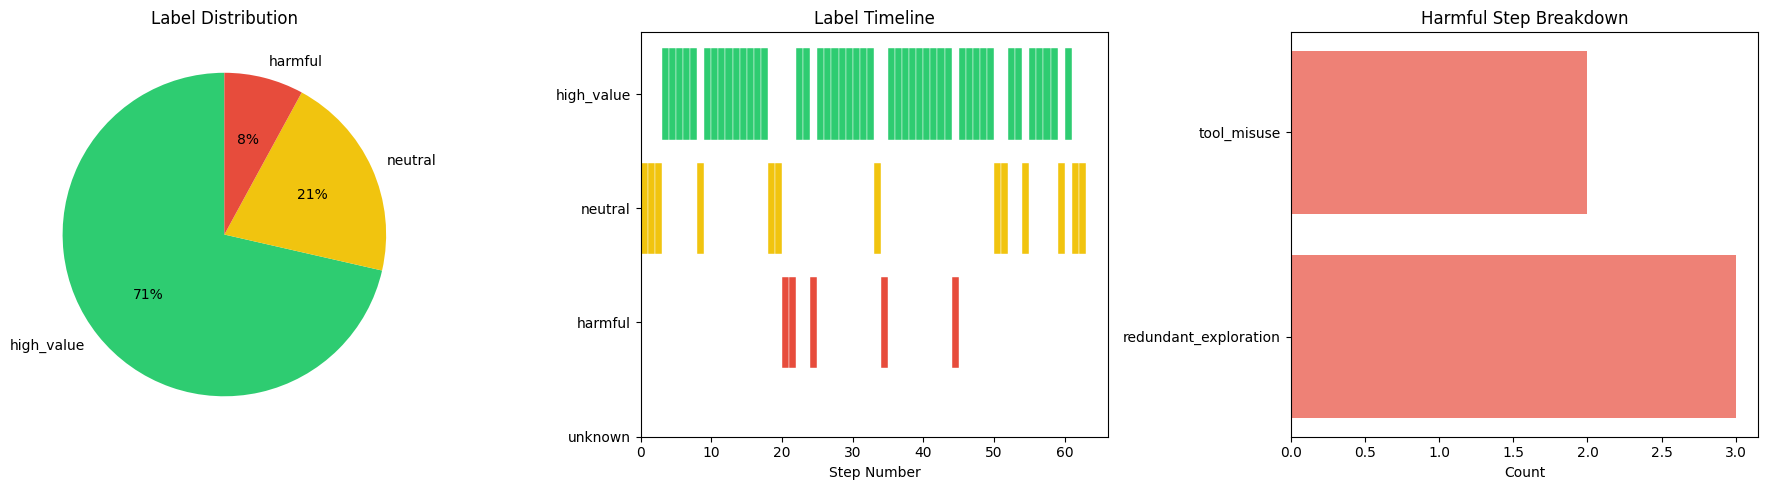

In [33]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pie chart of label distribution
ax = axes[0]
colors_map = {"high_value": "#2ecc71", "neutral": "#f1c40f", "harmful": "#e74c3c", "unknown": "#95a5a6"}
labels_order = [l for l in ["high_value", "neutral", "harmful", "unknown"] if l in label_counts]
counts_order = [label_counts[l] for l in labels_order]
colors_order = [colors_map[l] for l in labels_order]
ax.pie(counts_order, labels=labels_order, colors=colors_order, autopct="%1.0f%%",
       startangle=90, textprops={"fontsize": 10})
ax.set_title("Label Distribution")

# 2. Timeline: label per step
ax = axes[1]
label_to_y = {"high_value": 3, "neutral": 2, "harmful": 1, "unknown": 0}
for _, row in df_labels.iterrows():
    y = label_to_y.get(row["label"], 0)
    c = colors_map.get(row["label"], "gray")
    ax.barh(y, 1, left=row["step"], color=c, edgecolor="white", linewidth=0.3)
ax.set_yticks(list(label_to_y.values()))
ax.set_yticklabels(list(label_to_y.keys()))
ax.set_xlabel("Step Number")
ax.set_title("Label Timeline")

# 3. Harmful sub-label distribution
ax = axes[2]
if len(harmful) > 0:
    sub_counts = harmful["sub_label"].value_counts()
    ax.barh(range(len(sub_counts)), sub_counts.values, color="#e74c3c", alpha=0.7)
    ax.set_yticks(range(len(sub_counts)))
    ax.set_yticklabels(sub_counts.index)
    ax.set_xlabel("Count")
    ax.set_title("Harmful Step Breakdown")
else:
    ax.text(0.5, 0.5, "No harmful steps", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Harmful Step Breakdown")

plt.tight_layout()
plt.show()

## 6. Detailed Step Review

In [34]:
# Show all harmful steps with context
print("=" * 80)
print("HARMFUL STEPS (bad SFT training signal)")
print("=" * 80)

for _, row in df_labels[df_labels["label"] == "harmful"].iterrows():
    step_idx = row["step"]
    step = steps[step_idx]
    print(f"\n{'─' * 60}")
    print(f"Step {step_idx} | {row['action_type']} | {row['sub_label']}")
    print(f"Reason: {row['reason']}")
    if row['related_facts']:
        print(f"Related facts: {row['related_facts']}")
    print()
    print(format_step_for_prompt(step, max_chars=500))

HARMFUL STEPS (bad SFT training signal)

────────────────────────────────────────────────────────────
Step 20 | read | redundant_exploration
Reason: Re-reading test_nifti_saver.py which was already fully read in step 10.

### Step 20  [action: read]
**Thought**: Let me check what the actual test cases expect:
**Read**: /workspace/Project-MONAI__MONAI__0.2/tests/test_nifti_saver.py (lines -)
**File content**: Here's the result of running `cat -n` on /workspace/Project-MONAI__MONAI__0.2/tests/test_nifti_saver.py:
    28	            meta_data = {"filename_or_obj": ["testfile" + str(i) for i in range(8)]}
    29	            saver.save_batch(torch.zeros(8, 1, 2, 2), meta_data)
    30	            for i in range(8):
    31	                filepath = os.path.join("testfile" + str(i), "testfile" + str(i) + "_seg.nii.gz")
    32	                self.assertTrue(os.path.exists(os.path.join(tempdir, filepath)))


────────────────────────────────────────────────────────────
Step 21 | run | tool_misu

In [35]:
# Show all high-value steps
print("=" * 80)
print("HIGH-VALUE STEPS (good SFT training signal)")
print("=" * 80)

for _, row in df_labels[df_labels["label"] == "high_value"].iterrows():
    step_idx = row["step"]
    step = steps[step_idx]
    print(f"\n{'─' * 60}")
    print(f"Step {step_idx} | {row['action_type']}")
    print(f"Reason: {row['reason']}")
    if row['related_facts']:
        print(f"Related facts: {row['related_facts']}")
    print()
    print(format_step_for_prompt(step, max_chars=300))

HIGH-VALUE STEPS (good SFT training signal)

────────────────────────────────────────────────────────────
Step 3 | read
Reason: Reading the utils.py file that contains the buggy create_file_basename function mentioned in f2.
Related facts: f2

### Step 3  [action: read]
**Read**: /workspace/Project-MONAI__MONAI__0.2/monai/data/utils.py (lines -)
**File content**: Here's the result of running `cat -n` on /workspace/Project-MONAI__MONAI__0.2/monai/data/utils.py:
     1	# Copyright 2020 MONAI Consortium
     2	# Licensed under the Apache License, Version 2.0 (the "License");
     3	# you may not use this file except in compliance with the License.
     4	# You 

────────────────────────────────────────────────────────────
Step 4 | run
Reason: Finding the exact line number of create_file_basename function in utils.py.
Related facts: f2

### Step 4  [action: run]
**Command**: `grep -n "create_file_basename" /workspace/Project-MONAI__MONAI__0.2/monai/data/utils.py`
**Output** (exit_code=0): 

## 7. Fact Coverage Analysis

Which facts did the high-value steps cover?

In [36]:
# Analyze which fact graph nodes were referenced by high-value steps
all_fact_ids = set(n["id"] for n in nodes)

covered_facts: set[str] = set()
for lab in all_labels:
    if lab["label"] == "high_value":
        for fid in lab.get("related_facts", []):
            if fid in all_fact_ids:
                covered_facts.add(fid)

uncovered_facts = all_fact_ids - covered_facts

print(f"Fact graph coverage by high-value steps:")
print(f"  Total nodes:    {len(all_fact_ids)}")
print(f"  Covered:        {len(covered_facts)} ({len(covered_facts)/len(all_fact_ids):.0%})")
print(f"  Not covered:    {len(uncovered_facts)}")
print()

if uncovered_facts:
    print("Uncovered nodes:")
    for nid in sorted(uncovered_facts):
        node = next(n for n in nodes if n["id"] == nid)
        nt = node["node_type"]
        desc = node.get("statement", node.get("description", node.get("text", node.get("file", ""))))[:80]
        print(f"  [{nid}] ({nt}) {desc}")

Fact graph coverage by high-value steps:
  Total nodes:    24
  Covered:        15 (62%)
  Not covered:    9

Uncovered nodes:
  [analysis] (issue_analysis) The bug has two manifestations:

1. **create_file_basename**: The while loop at 
  [edit2] (code_edit) Change == to in for suffix matching in is_supported_format
  [edit3] (code_edit) Add blank line between data conversion and filename creation in NiftiSaver.save
  [f10] (fact) is_supported_format('1.3.12.2.1107.5.4.4.145.nii.gz', ['nii', 'nii.gz']) current
  [f11] (fact) is_supported_format is called by NibabelReader.verify_suffix (line 252 with suff
  [f15] (fact) For normal filenames like 'testfile.nii.gz', PurePath.suffixes returns ['.nii', 
  [plan] (fix_plan) 1. **monai/data/utils.py - create_file_basename**: Replace the while loop that s
  [val1] (validation) Run reproduce script after fix
  [val2] (validation) Run the fail-to-pass test test_value_5


## 8. Export Results

In [ ]:
# Save labeling results to JSON
output_dir = os.path.dirname(os.path.abspath("__file__"))
output_path = os.path.join(output_dir, f"labels_{TARGET_INSTANCE_ID}.json")

export_data = {
    "instance_id": TARGET_INSTANCE_ID,
    "model": LLM_MODEL,
    "total_steps": len(steps),
    "summary": {
        "high_value": int(label_counts.get("high_value", 0)),
        "neutral": int(label_counts.get("neutral", 0)),
        "harmful": int(label_counts.get("harmful", 0)),
        "unknown": int(label_counts.get("unknown", 0)),
        "sft_quality_score": round(sft_quality, 3),
        "harmful_ratio": round(harmful_ratio, 3),
    },
    "labels": all_labels,
}

with open(output_path, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Saved to: {output_path}")
print(f"  {export_data['summary']}")